In [1]:
#importing libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
data=yf.download('AMZN',start='2018-01-01',end='2026-12-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
data=pd.DataFrame(data)
data.head(30)

Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
2018-01-02,59.450500,59.500000,58.525501,58.599998,53890000
2018-01-03,60.209999,60.274502,59.415001,59.415001,62176000
2018-01-04,60.479500,60.793499,60.233002,60.250000,60442000
2018-01-05,61.457001,61.457001,60.500000,60.875500,70894000
2018-01-08,62.343498,62.653999,61.601501,61.799999,85590000
2018-01-09,62.634998,62.966499,62.088001,62.845001,73226000
2018-01-10,62.716499,62.716499,61.861500,62.257500,53720000
2018-01-11,63.834000,63.838501,62.823002,62.987000,62500000
2018-01-12,65.260002,65.288002,63.669498,63.669498,108874000


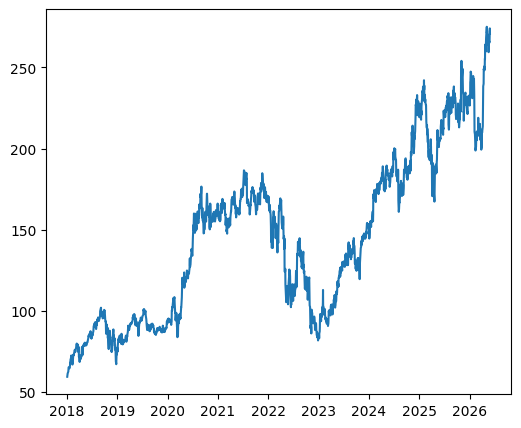

In [4]:
plt.figure(figsize=(6,5))
plt.plot(data.index,data['Close'])

In [5]:
# adding MACD,bollinger bands and RSI values
data['Middle']=data['Close'].rolling(window=20).mean()
data['Upper']=data['Close'].rolling(window=20).std()*2+data['Close'].rolling(window=20).mean()
data['Lower']=data['Close'].rolling(window=20).std()*(-2)+data['Close'].rolling(window=20).mean()

In [6]:
data=data.dropna()
data


Price,Close,High,Low,Open,Volume,Middle,Upper,Lower
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,,,
2018-01-30,71.890999,71.962502,69.599998,70.158501,117438000,65.095850,72.341727,57.849973
2018-01-31,72.544502,73.628998,72.501999,72.565002,128494000,65.750550,73.211717,58.289383
2018-02-01,69.500000,72.994003,69.257004,72.250000,182276000,66.215050,73.374486,59.055613
2018-02-02,71.497498,74.900002,70.699997,73.869499,222514000,66.765950,73.760853,59.771047
2018-02-05,69.500000,72.948997,66.036003,70.130997,229900000,67.168100,73.792882,60.543317
...,...,...,...,...,...,...,...,...
2026-05-22,266.320007,269.790009,266.239990,268.660004,27535500,267.095500,276.084350,258.106650
2026-05-26,265.290009,269.299988,262.070007,267.940002,38028100,267.304001,275.893847,258.714154
2026-05-27,271.850006,272.410004,265.700012,266.149994,40061900,267.911501,275.937057,259.885945


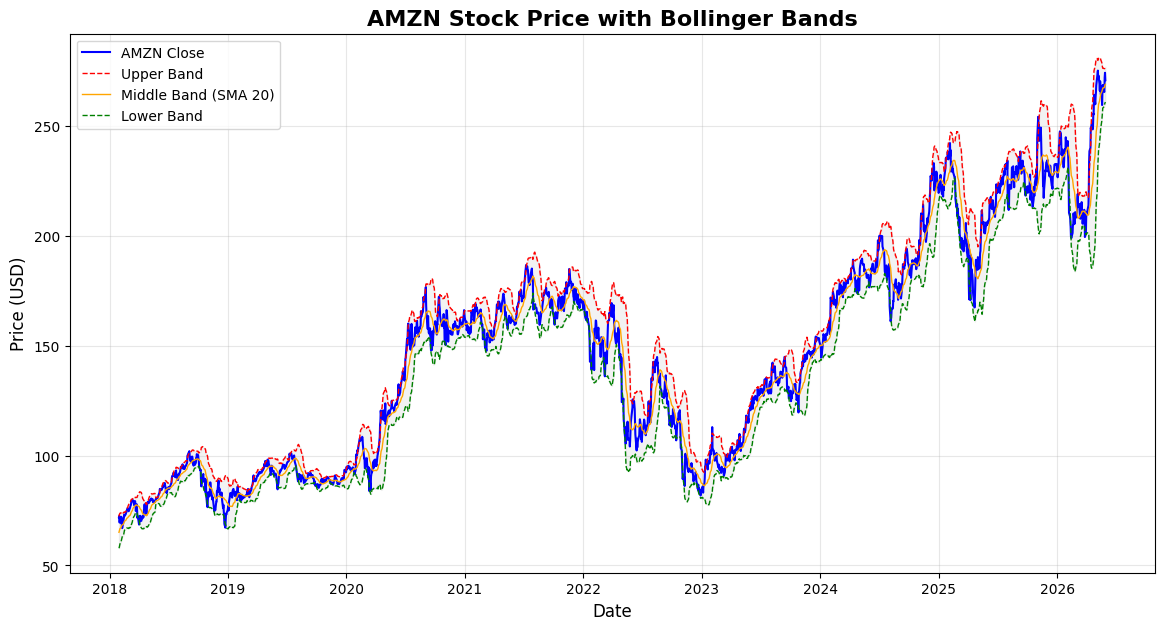

In [7]:

# 1. Set up a clean, wide figure size
plt.figure(figsize=(14, 7))

# 2. Plot the Close Price (Specifying the MultiIndex columns correctly)
plt.plot(data.index, data[('Close', 'AMZN')], label='AMZN Close', color='blue', linewidth=1.5)

# 3. Plot the Bollinger Bands
plt.plot(data.index, data['Upper'], label='Upper Band', color='red', linestyle='--', linewidth=1)
plt.plot(data.index, data['Middle'], label='Middle Band (SMA 20)', color='orange', linestyle='-', linewidth=1)
plt.plot(data.index, data['Lower'], label='Lower Band', color='green', linestyle='--', linewidth=1)

# 4. Fill the space between the Upper and Lower bands with a light transparent shade
plt.fill_between(data.index, data['Upper'], data['Lower'], color='gray', alpha=0.1)

# 5. Add titles, labels, and formatting
plt.title('AMZN Stock Price with Bollinger Bands', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=10)

# 6. Display the graph
plt.show()

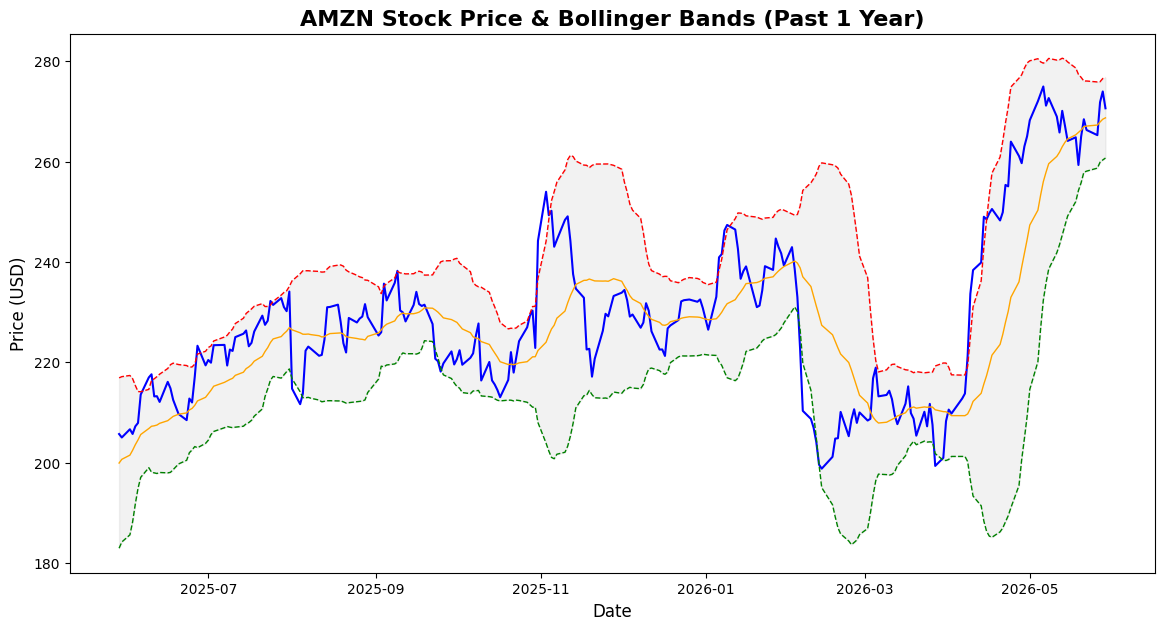

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Ensure the index is recognized as a Datetime index
data.index = pd.to_datetime(data.index)

# 2. Filter for the last 1 year of data from the latest date available
one_year_ago = data.index.max() - pd.DateOffset(years=1)
plot_data = data.loc[one_year_ago:]

# 3. Create the plot with the shortened data (plot_data)
plt.figure(figsize=(14, 7))

# Plot Close Price (using the MultiIndex tuple format matching your data)
plt.plot(plot_data.index, plot_data[('Close', 'AMZN')], label='AMZN Close', color='blue', linewidth=1.5)

# Plot Bollinger Bands
plt.plot(plot_data.index, plot_data['Upper'], label='Upper Band', color='red', linestyle='--', linewidth=1)
plt.plot(plot_data.index, plot_data['Middle'], label='Middle Band', color='orange', linestyle='-', linewidth=1)
plt.plot(plot_data.index, plot_data['Lower'], label='Lower Band', color='green', linestyle='--', linewidth=1)

# Fill the volatility channel
plt.fill_between(plot_data.index, plot_data['Upper'], plot_data['Lower'], color='gray', alpha=0.1)

# 4. Labels and Styling
plt.title('AMZN Stock Price & Bollinger Bands (Past 1 Year)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
# 5. Display the graph
plt.show()

In [9]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [col[0] for col in data.columns]

In [10]:
# backtesting strategy using Bollinger Bands
#if the bprice goes above or equal to th upper band then sell and if the price goes below the lower level buy
condition =[
    data['Close']>data['Upper'],
    data['Close']<data['Lower'],
]
option=[1,-1]
data['Signal']= np.select(condition,option,default=0)
position=0
position_l=[]
for signal in data['Signal']:
    if signal==1:
        position=1
    elif signal==0:
        position=0
    position_l.append(position)


data['position_l']=position_l
data["Market_Open_Returns"] = data["Open"].pct_change()

# Shift position state by 1 day because today's state dictates tomorrow morning's exposure
data["Strategy_Returns"] = data["Market_Open_Returns"] * data["position_l"].shift(1)
data["Total_Return"] = (1 + data["Strategy_Returns"].fillna(0)).cumprod()

# 6. Output Summary
final_pct = (data["Total_Return"].iloc[-1] - 1) * 100
print(f"--- 3-State Backtest Complete ---")
print(f"Final Strategy Growth Multiplier: {data['Total_Return'].iloc[-1]:.2f}x")
print(f"Total Strategy Return: {final_pct:.2f}%")

--- 3-State Backtest Complete ---
Final Strategy Growth Multiplier: 7.07x
Total Strategy Return: 606.56%
